# Getting Started with jaxCAD

In [1]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcad.render import render_raymarched
from jaxcad.sdf.boolean import Union
from jaxcad.sdf.primitives import Box, Capsule, Cylinder, RoundBox, Sphere, Torus
from jaxcad.sdf.transforms import Translate

jaxCAD provides a set of primitive shapes (sphere, box, capsule, cylinder, torus, …), affine transforms (translate, rotate, scale), and boolean operations (union, intersection, difference). Below we position several primitives in space and combine them with a smooth union.

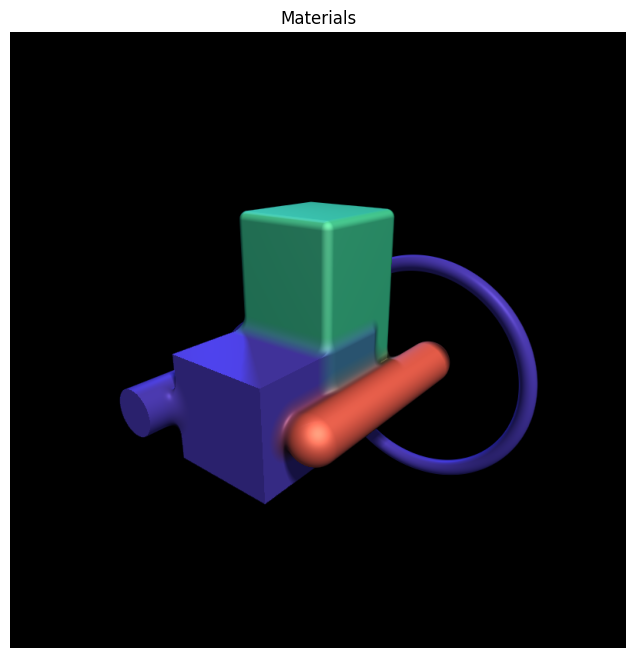

In [2]:
import random

from jaxcad.render import Material

mat_coral = Material(color=[0.97, 0.40, 0.35], roughness=0.4, metallic=0.0)
mat_indigo = Material(color=[0.33, 0.27, 0.90], roughness=0.2, metallic=0.8)
mat_mint = Material(color=[0.18, 0.80, 0.62], roughness=0.6, metallic=0.0)
mats = [mat_coral, mat_indigo, mat_mint]

random.seed(0)

sphere = Sphere(radius=0.6, material=random.choice(mats))
sphere = Translate(sphere, offset=jnp.array([-1.0, 0.0, 0.0]))

box = Box(size=[0.7, 0.7, 1.0], material=random.choice(mats))
box = Translate(box, offset=jnp.array([0.0, 0.0, 0.8]))

capsule = Capsule(radius=0.3, height=1.3, material=random.choice(mats))
capsule = Translate(capsule, offset=jnp.array([1.0, 0.0, 0.0]))

cylinder = Cylinder(radius=0.3, height=1.0, material=random.choice(mats))
cylinder = Translate(cylinder, offset=jnp.array([-1.0, 0.0, 1.2]))

round_box = RoundBox(size=[0.6, 0.9, 0.6], radius=0.1, material=random.choice(mats))
round_box = Translate(round_box, offset=jnp.array([0.0, 1.2, 0.0]))

torus = Torus(major_radius=1.5, minor_radius=0.1, material=random.choice(mats))
torus = Translate(torus, offset=jnp.array([1.0, 0.0, -1.0]))

scene = Union((sphere, box, capsule, cylinder, round_box, torus), smoothness=0.05)

render_raymarched(
    scene,
    camera_pos=jnp.array([4.0, 3.0, 5.0]),
    look_at=jnp.array([0.0, 0.5, 0.0]),
    light_dirs=jnp.array([[1.5, 2.0, 1.0], [-1.0, 0.5, -0.8]]),
    light_colors=jnp.array([[1.0, 0.92, 0.75], [0.25, 0.35, 0.65]]),
    resolution=(800, 800),
    aa_samples=1,
    title="Materials",
)
plt.show()

Deformations can be layered on top of any SDF. Here we apply a `Twist` along the Y-axis to the scene above.

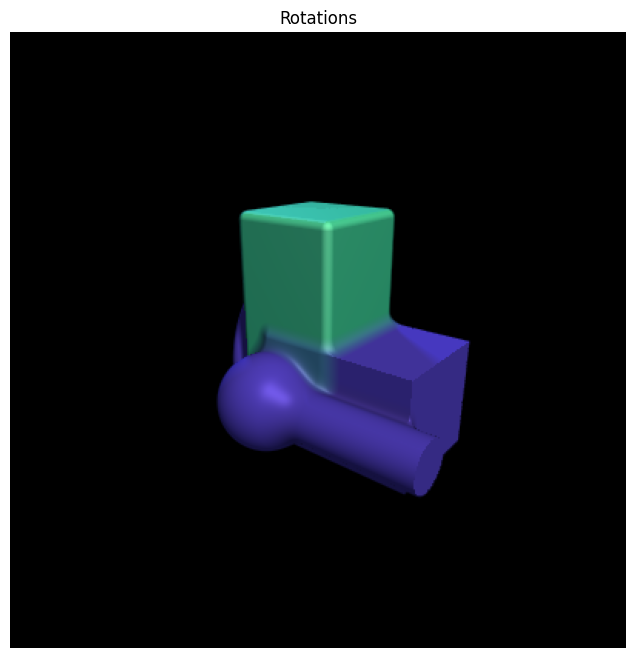

In [3]:
from jaxcad.sdf.transforms.affine import Rotate

scene_ = Rotate(scene, angle=jnp.pi / 2, axis=jnp.array([0.0, 1.0, 0.0]))

render_raymarched(
    scene_,
    camera_pos=jnp.array([4.0, 3.0, 5.0]),
    look_at=jnp.array([0.0, 0.5, 0.0]),
    light_dirs=jnp.array([[1.5, 2.0, 1.0], [-1.0, 0.5, -0.8]]),
    light_colors=jnp.array([[1.0, 0.92, 0.75], [0.25, 0.35, 0.65]]),
    resolution=(400, 400),
    aa_samples=1,
    title="Rotations",
)
plt.show()

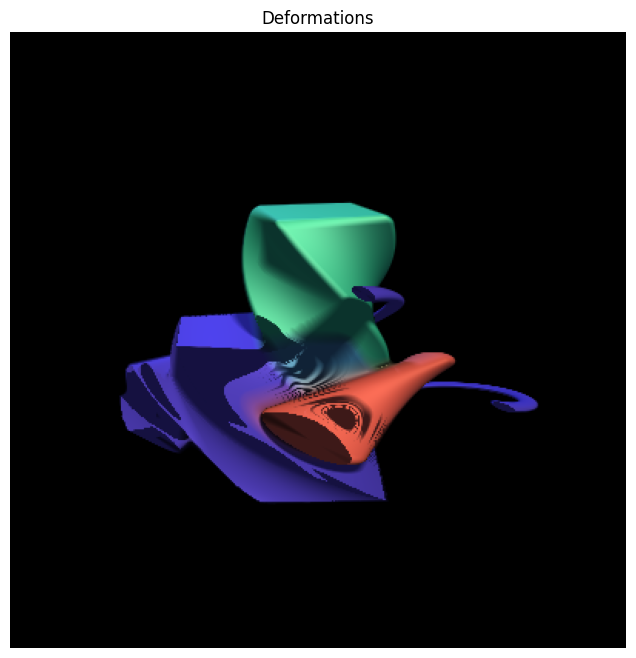

In [4]:
from jaxcad.sdf.transforms.deformations import Twist

scene_ = Twist(scene, strength=1.0, axis=jnp.array([0.0, 1.0, 0.0]))

render_raymarched(
    scene_,
    camera_pos=jnp.array([4.0, 3.0, 5.0]),
    look_at=jnp.array([0.0, 0.5, 0.0]),
    light_dirs=jnp.array([[1.5, 2.0, 1.0], [-1.0, 0.5, -0.8]]),
    light_colors=jnp.array([[1.0, 0.92, 0.75], [0.25, 0.35, 0.65]]),
    resolution=(400, 400),
    aa_samples=1,
    title="Deformations",
)
plt.show()